In [61]:
# Loading stuff

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.linear_model import Lasso, ElasticNet

In [62]:
# --- Loading all the datasets
# Train dataset
train_dataset = pd.read_csv('data/train_radiomics_hipocamp.csv')
# Test dataset
test_dataset = pd.read_csv('data/test_radiomics_hipocamp.csv')

In [63]:
# --- Exploring the train dataset
train_dataset.head()
train_dataset.columns
train_dataset.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 2181 columns):
 #     Column                                                         Non-Null Count  Dtype  
---    ------                                                         --------------  -----  
 0     ID                                                             305 non-null    object 
 1     Image                                                          305 non-null    object 
 2     Mask                                                           305 non-null    object 
 3     diagnostics_Versions_PyRadiomics                               305 non-null    object 
 4     diagnostics_Versions_Numpy                                     305 non-null    object 
 5     diagnostics_Versions_SimpleITK                                 305 non-null    object 
 6     diagnostics_Versions_PyWavelet                                 305 non-null    object 
 7     diagnostics_Versions_Python             

In [64]:
# --- Removing columns with irrelevant information

# Getting all columns whose value is an object
obj_col = train_dataset.select_dtypes(include='object').columns

# Storing in a list the columns that have the same number of unique values as the number of rows
# This means that the column is a unique identifier and probably should be dropped
unique_cols = []
for col in obj_col:
    if train_dataset[col].nunique() == 305:
        unique_cols.append(col)

# list of columns that will be dropped
print(unique_cols)

# dataset with the columns that will be dropped
train_dataset[unique_cols].head()

# The following features might actually be useful:
# - diagnostics_Mask-original_BoundingBox
# - diagnostics_Mask-original_CenterOfMassIndex
# - diagnostics_Mask-original_CenterOfMass

# removing last 3 columns from the 'unique_cols' - we don't want to drop them
unique_cols.remove('diagnostics_Mask-original_BoundingBox')
unique_cols.remove('diagnostics_Mask-original_CenterOfMassIndex')
unique_cols.remove('diagnostics_Mask-original_CenterOfMass')
        
# Dropping the columns stored in the unique_cols list
train_dataset.drop(unique_cols, axis=1, inplace=True)
# Dropping them from the test dataset as well
test_dataset.drop(unique_cols, axis=1, inplace=True)

pd.set_option('display.max_colwidth', None)
display(train_dataset['diagnostics_Mask-original_BoundingBox'].head())
display(train_dataset['diagnostics_Mask-original_CenterOfMassIndex'].head())
display(train_dataset['diagnostics_Mask-original_CenterOfMass'].head())

['ID', 'Image', 'Mask', 'diagnostics_Image-original_Hash', 'diagnostics_Mask-original_Hash', 'diagnostics_Mask-original_BoundingBox', 'diagnostics_Mask-original_CenterOfMassIndex', 'diagnostics_Mask-original_CenterOfMass']


0    (103, 113, 93, 36, 30, 71)
1     (81, 127, 93, 47, 16, 73)
2     (77, 119, 89, 49, 30, 81)
3     (93, 102, 90, 41, 29, 78)
4     (87, 119, 91, 40, 27, 75)
Name: diagnostics_Mask-original_BoundingBox, dtype: object

0    (121.94230227976358, 129.27272727272728, 128.40402476780187)
1    (107.06170458927883, 135.28088443244633, 128.27458542229078)
2     (103.3640972118682, 135.28164604144922, 128.98628298792306)
3     (116.29827315541601, 118.67431469629271, 129.3098659582176)
4    (108.26561977948546, 132.05462746408287, 127.67206815903775)
Name: diagnostics_Mask-original_CenterOfMassIndex, dtype: object

0    (121.94230227976358, 129.27272727272728, 128.40402476780187)
1    (107.06170458927883, 135.28088443244633, 128.27458542229078)
2     (103.3640972118682, 135.28164604144922, 128.98628298792306)
3     (116.29827315541601, 118.67431469629271, 129.3098659582176)
4    (108.26561977948546, 132.05462746408287, 127.67206815903775)
Name: diagnostics_Mask-original_CenterOfMass, dtype: object

In [65]:
# Check if 'diagnostics_Mask-original_CenterOfMassIndex' and 'diagnostics_Mask-original_CenterOfMass' are the same
# If they are, we can drop one of them

(train_dataset['diagnostics_Mask-original_CenterOfMassIndex'] == train_dataset['diagnostics_Mask-original_CenterOfMass']).all()

# They are the same, so we can drop one of them
train_dataset.drop('diagnostics_Mask-original_CenterOfMass', axis=1, inplace=True)
test_dataset.drop('diagnostics_Mask-original_CenterOfMass', axis=1, inplace=True)

In [66]:
# --- Transfoming the 'diagnostics_Mask-original_BoundingBox' feature into useful data
# Splitting the string into 6 different columns
# probably x,y,z,width,height,depth -> most common

train_dataset['diagnostics_Mask-original_BoundingBox'] = train_dataset['diagnostics_Mask-original_BoundingBox'].str.replace('(', '').str.replace(')', '')
train_dataset['diagnostics_Mask-original_BoundingBox'] = train_dataset['diagnostics_Mask-original_BoundingBox'].str.split(',').apply(lambda x: [int(i) for i in x])
train_dataset[['x', 'y', 'z', 'width', 'height', 'depth']] = pd.DataFrame(train_dataset['diagnostics_Mask-original_BoundingBox'].tolist(), index=train_dataset.index)
train_dataset.drop('diagnostics_Mask-original_BoundingBox', axis=1, inplace=True)

# Doing the same for the test dataset
test_dataset['diagnostics_Mask-original_BoundingBox'] = test_dataset['diagnostics_Mask-original_BoundingBox'].str.replace('(', '').str.replace(')', '')
test_dataset['diagnostics_Mask-original_BoundingBox'] = test_dataset['diagnostics_Mask-original_BoundingBox'].str.split(',').apply(lambda x: [int(i) for i in x])
test_dataset[['x', 'y', 'z', 'width', 'height', 'depth']] = pd.DataFrame(test_dataset['diagnostics_Mask-original_BoundingBox'].tolist(), index=test_dataset.index)
test_dataset.drop('diagnostics_Mask-original_BoundingBox', axis=1, inplace=True)

# Calculating the volume of the bounding box
train_dataset['volume'] = train_dataset['width'] * train_dataset['height'] * train_dataset['depth']
test_dataset['volume'] = test_dataset['width'] * test_dataset['height'] * test_dataset['depth']

In [67]:
# --- Transfoming the 'diagnostics_Mask-original_CenterOfMassIndex' feature into useful data
# Splitting the string into 3 different columns

# Removing '(' and ')' from the string
train_dataset['diagnostics_Mask-original_CenterOfMassIndex'] = train_dataset['diagnostics_Mask-original_CenterOfMassIndex'].str.replace('(', '').str.replace(')', '')
train_dataset['diagnostics_Mask-original_CenterOfMassIndex'] = train_dataset['diagnostics_Mask-original_CenterOfMassIndex'].str.split(',').apply(lambda x: [float(i) for i in x])
train_dataset[['x_center', 'y_center', 'z_center']] = pd.DataFrame(train_dataset['diagnostics_Mask-original_CenterOfMassIndex'].tolist(), index=train_dataset.index)
train_dataset.drop('diagnostics_Mask-original_CenterOfMassIndex', axis=1, inplace=True)

# Doing the same for the test dataset
test_dataset['diagnostics_Mask-original_CenterOfMassIndex'] = test_dataset['diagnostics_Mask-original_CenterOfMassIndex'].str.replace('(', '').str.replace(')', '')
test_dataset['diagnostics_Mask-original_CenterOfMassIndex'] = test_dataset['diagnostics_Mask-original_CenterOfMassIndex'].str.split(',').apply(lambda x: [float(i) for i in x])
test_dataset[['x_center', 'y_center', 'z_center']] = pd.DataFrame(test_dataset['diagnostics_Mask-original_CenterOfMassIndex'].tolist(), index=test_dataset.index)
test_dataset.drop('diagnostics_Mask-original_CenterOfMassIndex', axis=1, inplace=True)

# Calculating the distance from the center of mass to the bounding box
train_dataset['distance'] = np.sqrt((train_dataset['x'] - train_dataset['x_center'])**2 + (train_dataset['y'] - train_dataset['y_center'])**2 + (train_dataset['z'] - train_dataset['z_center'])**2)
test_dataset['distance'] = np.sqrt((test_dataset['x'] - test_dataset['x_center'])**2 + (test_dataset['y'] - test_dataset['y_center'])**2 + (test_dataset['z'] - test_dataset['z_center'])**2)

In [68]:
train_dataset.shape

(305, 2184)

In [69]:
# --- Dropping constant features
train_dataset = train_dataset.loc[:, (train_dataset != train_dataset.iloc[0]).any()]

# Dropping the same columns on the test dataset
test_dataset = test_dataset[train_dataset.drop(columns='Transition').columns]

In [70]:
# --- Checking all unique values in the Transition column
train_dataset['Transition'].value_counts()
# Dataset is extremely UNBALANCED

Transition
CN-CN      96
MCI-MCI    71
MCI-AD     68
AD-AD      60
CN-MCI     10
Name: count, dtype: int64

In [71]:
# --- Using encoding to transform the target columns into numeric values
replace_map = {'Transition': {'CN-CN': 0, 'AD-AD': 1, 'CN-MCI': 2, 'MCI-AD': 3, 'MCI-MCI': 4}}
train_dataset.replace(replace_map, inplace=True)
test_dataset.replace(replace_map, inplace=True)
train_dataset.head()

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_2528\739912594.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_dataset.replace(replace_map, inplace=True)


diagnostics_Image-original_Mean  diagnostics_Image-original_Maximum  \
0                         5.848123                                 178   
1                         5.238834                                 190   
2                         6.816667                                 155   
3                         6.445162                                 171   
4                         5.568269                                 150   

   diagnostics_Mask-original_VoxelNum  original_shape_Elongation  \
0                                7106                   0.420040   
1                                7779                   0.425482   
2                                6707                   0.447685   
3                                8281                   0.418896   
4                                5986                   0.411851   

   original_shape_Flatness  original_shape_LeastAxisLength  \
0                 0.106547                       10.757474   
1                 0.102532                       10.432362   
2                 0.135582                       14.370911   
3                 0.099626                       10.639815   
4                 0.080719                        8.885188   

   original_shape_MajorAxisLength  original_shape_Maximum2DDiameterColumn  \
0                      100.964915                               72.034714   
1                      101.747321                               73.246160   
2                      105.993915                               79.762146   
3                      106.797600                               78.102497   
4                      110.075144                               75.432089   

   original_shape_Maximum2DDiameterRow  original_shape_Maximum2DDiameterSlice  \
0                            71.175839                              43.416587   
1                            73.109507                              44.102154   
2                            79.056942                              47.853944   
3                            77.006493                              45.793013   
4                            75.239617                              43.462628   

   original_shape_Maximum3DDiameter  original_shape_MeshVolume  \
0                         72.034714                7033.166667   
1                         73.252986                7716.583333   
2                         81.154174                6636.083333   
3                         78.217645                8248.583333   
4                         75.848533                5897.791667   

   original_shape_MinorAxisLength  original_shape_Sphericity  \
0                       42.409319                   0.396075   
1                       43.291655                   0.420557   
2                       47.451935                   0.315524   
3                       44.737083                   0.401709   
4                       45.334518                   0.390626   

   original_shape_SurfaceArea  original_shape_SurfaceVolumeRatio  \
0                 4482.023762                           0.637270   
1                 4490.310227                           0.581904   
2                 5412.437400                           0.815607   
3                 4914.650931                           0.595818   
4                 4041.249915                           0.685214   

   original_shape_VoxelVolume  original_firstorder_10Percentile  \
0                        7106                              56.0   
1                        7779                              56.0   
2                        6707                              34.0   
3                        8281                              59.0   
4                        5986                              60.0   

   original_firstorder_90Percentile  original_firstorder_Energy  \
0                              83.0                    35914043   
1                              82.0                    38292768   
2                              

In [72]:
train_dataset['Transition'].value_counts()

Transition
0    96
4    71
3    68
1    60
2    10
Name: count, dtype: int64

In [73]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Columns: 2025 entries, diagnostics_Image-original_Mean to distance
dtypes: float64(1998), int64(27)
memory usage: 4.7 MB


In [74]:
# --- Droppig non-target columns with the same info (correlation = 1 between them)

target_column = 'Transition'  
# Calculating the correlation matrix (excluding the target column)
train_dataset_tmp = train_dataset 
corr_matrix_train = train_dataset_tmp.drop(columns=[target_column]).corr().abs()

# Upper triangle matrix of correlations
upper = corr_matrix_train.where(np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool))

# Finding index of feature columns with correlation equal to 1
threshold = 1.0
to_drop = [column for column in upper.columns if any(upper[column] >= threshold)] # for some reason there are columns with correlation > 1.0
print("dropping " + str(len(to_drop)) + " columns")

# Dropping the columns
train_dataset = train_dataset.drop(columns=to_drop)
test_dataset = test_dataset.drop(columns=to_drop)

dropping 137 columns


In [75]:
# Checking dataset info
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Columns: 1888 entries, diagnostics_Image-original_Mean to distance
dtypes: float64(1868), int64(20)
memory usage: 4.4 MB


In [76]:
## --- Dropping columns with low correlation with the target column (<0.005)

#corr_matrix = train_dataset.corr()
#corr_target = corr_matrix['Transition'].abs()
#uncorr_cols = []
#for i in range(len(corr_target)):
#    if corr_target[i] < 0.005:
#        uncorr_cols.append(corr_matrix.columns[i])
#
## Dropping the columns stored in the uncorr_cols list
#n_cols_before = len(train_dataset.columns)
#train_dataset.drop(uncorr_cols, axis=1, inplace=True)
#test_dataset.drop(uncorr_cols, axis=1, inplace=True)
#n_cols_after = len(train_dataset.columns)
#
#print("Dropped " + str(n_cols_before-n_cols_after) + " columns!")

Axes(0.125,0.11;0.775x0.77)


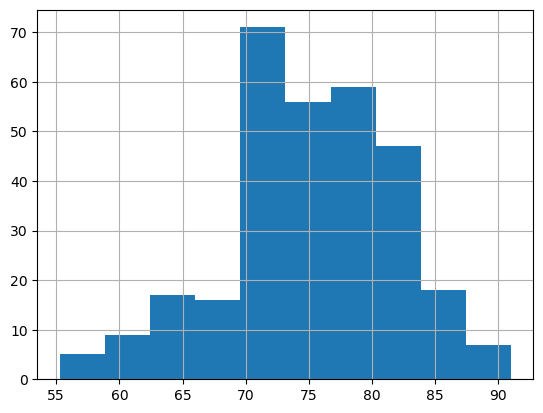

In [77]:
# --- Checking Age column
print(train_dataset['Age'].hist())
plt.show()
# Not a normal distribution

In [78]:
# --- Checking Sex column
print(train_dataset['Sex'].value_counts(normalize=True))
# Not quite balanced

Sex
1    0.567213
0    0.432787
Name: proportion, dtype: float64


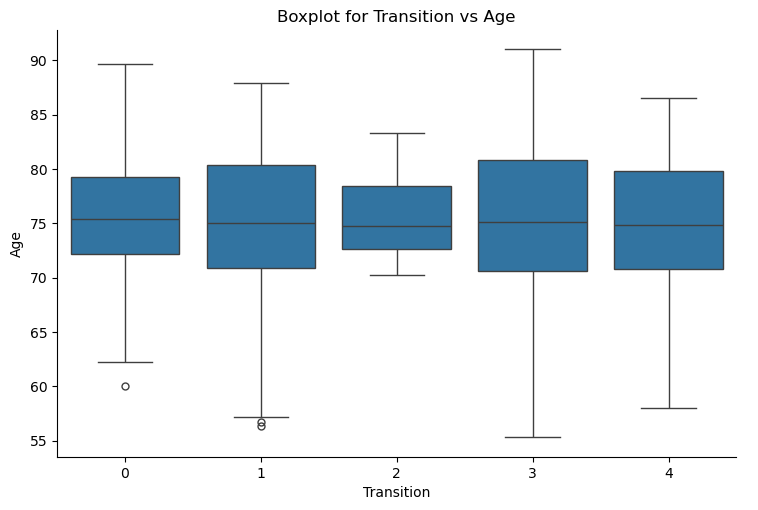

In [79]:
# --- Understanding the relationship between Age and Transition
sns.catplot(x="Transition", y="Age", data=train_dataset, kind="box", aspect=1.5)
plt.title("Boxplot for Transition vs Age")
plt.show()

In [80]:
# --- Treating outliers
# Outliers should be converted to the closest bound

changes_count = 0

for col in train_dataset.columns:
    if col not in ['Transition', 'ID']:
        median = train_dataset[col].median()
        q1 = train_dataset[col].quantile(0.25)
        q3 = train_dataset[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Count outliers before replacing them
        changes_count += ((train_dataset[col] < lower_bound) | (train_dataset[col] > upper_bound)).sum()
        changes_count += ((test_dataset[col] < lower_bound) | (test_dataset[col] > upper_bound)).sum()
        
        # Replace outliers with the median
        # train_dataset[col] = train_dataset[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
        # test_dataset[col] = test_dataset[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

        # Replace outliers with the closest bound
        train_dataset[col] = train_dataset[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
        test_dataset[col] = test_dataset[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

print(f"Total number of changes made: {changes_count}")

Total number of changes made: 26068


In [81]:
# --- Standardizing data

# Use the same scaler for both datasets

scaler = StandardScaler()
columns_to_scale = train_dataset.drop(columns=['Transition']).columns
train_dataset[columns_to_scale] = scaler.fit_transform(train_dataset[columns_to_scale])
test_dataset[columns_to_scale] = scaler.transform(test_dataset[columns_to_scale])

In [82]:
# Add an 'oversampled' column to the dataset with 'NO' values
# This will be used to guarantee oversampling data is not used in testing
train_dataset['oversampled'] = 'NO'

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_2528\3994889019.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_dataset['oversampled'] = 'NO'


In [83]:
# --- Oversampling data
### Oversampling should be done after standardizing but before feature selection and dimensionality reduction

# Split the dataset into features and target
X = train_dataset.drop(columns=['Transition', 'oversampled'])
y = train_dataset['Transition']

# Identify the majority class count (class '0')
majority_class_count = y.value_counts().loc[0]

# Set the target count for class '2' to be 0.5 of the majority class count
target_class_2_count = int(majority_class_count * 0.3)
target_class_1_count = int(majority_class_count * 1)
target_class_3_count = int(majority_class_count * 1)
target_class_4_count = int(majority_class_count * 1)

# Define a sampling strategy where only class '2' is oversampled to the target count
sampling_strategy = {2: target_class_2_count,
#                     1: target_class_1_count,
#                     3: target_class_3_count,
#                     4: target_class_4_count
}

# Apply SMOTE with the defined strategy
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=123)
X_smote, y_smote = smote.fit_resample(X, y)

# Create a new dataframe with the oversampled data
oversampled_data = pd.concat([X_smote, y_smote], axis=1)
oversampled_data.columns = list(X.columns) + ['Transition']

# Mark the oversampled rows with 'YES' in the 'oversampled' column
oversampled_data['oversampled'] = ['YES' if idx >= len(X) else 'NO' for idx in range(len(X_smote))]

# Concatenate the new oversampled data with the original data
train_dataset = pd.concat([train_dataset, oversampled_data[oversampled_data['oversampled'] == 'YES']], ignore_index=True)

# Display the final class distribution for verification
print("Class distribution after SMOTE oversampling:")
print(train_dataset['Transition'].value_counts())

# --- Getting the number of normal and oversampled data
train_dataset['oversampled'].value_counts()

Class distribution after SMOTE oversampling:
Transition
0    96
4    71
3    68
1    60
2    28
Name: count, dtype: int64


oversampled
NO     305
YES     18
Name: count, dtype: int64

In [84]:
## --- Feature selection with ANOVA
#
#f, p = f_classif(X, y)
#f_classif_importances = f
#features_to_keep = X.columns[f_classif_importances.argsort()[-200:]]
### Keeping only the selected features
#X = X[list(features_to_keep)]
## Dropping the non-selected columns from the test dataset as well
#test_dataset = test_dataset[features_to_keep]
#print('Number of features:', len(features_to_keep))

In [85]:
## --- Dimensionality reduction with PCA
#
#pca = PCA(n_components=100) 
#pca.fit(X)
#data = pca.transform(X)
#train_dataset_no_target = pd.DataFrame(data)
#train_dataset = pd.concat([train_dataset_no_target, train_dataset['Transition'], train_dataset['oversampled']], axis=1)
#
#data_test = pca.transform(test_dataset)
#test_dataset = pd.DataFrame(data_test)

In [86]:
train_dataset.shape

(323, 1889)

In [87]:
train_dataset.head()

diagnostics_Image-original_Mean  diagnostics_Image-original_Maximum  \
0                         0.061441                            0.195130   
1                        -0.932747                            0.701818   
2                         1.641832                           -0.776021   
3                         1.035641                           -0.100438   
4                        -0.395202                           -0.987141   

   diagnostics_Mask-original_VoxelNum  original_shape_Elongation  \
0                            0.367332                   0.284298   
1                            1.000047                   0.472647   
2                           -0.007785                   1.241132   
3                            1.471998                   0.244696   
4                           -0.685627                   0.000850   

   original_shape_Flatness  original_shape_LeastAxisLength  \
0                 1.106082                        0.775289   
1                 0.655583                        0.383641   
2                 2.686888                        2.633326   
3                 0.329478                        0.633551   
4                -1.792137                       -1.480171   

   original_shape_MajorAxisLength  original_shape_Maximum2DDiameterColumn  \
0                       -0.639064                               -0.635245   
1                       -0.510551                               -0.335183   
2                        0.186964                                1.278756   
3                        0.318971                                0.867679   
4                        0.857317                                0.206248   

   original_shape_Maximum2DDiameterRow  original_shape_Maximum2DDiameterSlice  \
0                            -0.861735                               0.134162   
1                            -0.378730                               0.414690   
2                             1.106861                               1.949888   
3                             0.594686                               1.106573   
4                             0.153344                               0.153001   

   original_shape_Maximum3DDiameter  original_shape_MeshVolume  \
0                         -0.980527                   0.360095   
1                         -0.672405                   1.005974   
2                          1.325938                  -0.015178   
3                          0.583241                   1.508752   
4                         -0.015948                  -0.712918   

   original_shape_MinorAxisLength  original_shape_Sphericity  \
0                       -0.267477                   0.452244   
1                        0.081320                   1.757680   
2                        1.725921                  -2.847002   
3                        0.652713                   0.752647   
4                        0.888885                   0.161709   

   original_shape_SurfaceArea  original_shape_SurfaceVolumeRatio  \
0                    0.204797                          -0.524813   
1                    0.225405                          -1.429895   
2                    2.518758                           2.390532   
3                    1.280751                          -1.202444   
4                   -0.891418                           0.258951   

   original_firstorder_10Percentile  original_firstorder_90Percentile  \
0                          0.376350                          0.173894   
1                          0.376350                         -0.318563   
2                         -2.611692                          0.173894   
3                          1.065898                          1.651265   
4                          1.295748                          0.173894   

   original_firstorder_Energy  original_firstorder_Entropy  \
0                    0.446447                    -0.049571   
1                    0.833650                    -1.008320   
2         

In [88]:
# --- Checking feature importance for the engineered features

# Split the dataset into features and target
from sklearn.ensemble import RandomForestClassifier


X = train_dataset.drop(columns=['Transition', 'oversampled'])
y = train_dataset['Transition']

# Use RandomForest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=123)
rf.fit(X, y)
importances = rf.feature_importances_
importance_indices = importances.argsort()[::-1]
features_to_keep = X.columns[importance_indices]

# Check rankings of created features
feature_names = ['volume', 'distance', 'x', 'y', 'z', 'width', 'height', 'depth', 
                'x_center', 'y_center', 'z_center']

for feature in feature_names:
    feature_index = list(X.columns).index(feature)
    rank = np.where(importance_indices == feature_index)[0][0]
    print(f"Ranking of '{feature}': {rank} out of {len(importance_indices)}")



Ranking of 'volume': 1715 out of 1887
Ranking of 'distance': 969 out of 1887
Ranking of 'x': 897 out of 1887
Ranking of 'y': 935 out of 1887
Ranking of 'z': 1380 out of 1887
Ranking of 'width': 1034 out of 1887
Ranking of 'height': 1794 out of 1887
Ranking of 'depth': 1545 out of 1887
Ranking of 'x_center': 758 out of 1887
Ranking of 'y_center': 220 out of 1887
Ranking of 'z_center': 89 out of 1887


In [89]:
# guaranteeing all columns are shown on .head

pd.set_option('display.max_columns', None)

train_dataset.head()

diagnostics_Image-original_Mean  diagnostics_Image-original_Maximum  \
0                         0.061441                            0.195130   
1                        -0.932747                            0.701818   
2                         1.641832                           -0.776021   
3                         1.035641                           -0.100438   
4                        -0.395202                           -0.987141   

   diagnostics_Mask-original_VoxelNum  original_shape_Elongation  \
0                            0.367332                   0.284298   
1                            1.000047                   0.472647   
2                           -0.007785                   1.241132   
3                            1.471998                   0.244696   
4                           -0.685627                   0.000850   

   original_shape_Flatness  original_shape_LeastAxisLength  \
0                 1.106082                        0.775289   
1                 0.655583                        0.383641   
2                 2.686888                        2.633326   
3                 0.329478                        0.633551   
4                -1.792137                       -1.480171   

   original_shape_MajorAxisLength  original_shape_Maximum2DDiameterColumn  \
0                       -0.639064                               -0.635245   
1                       -0.510551                               -0.335183   
2                        0.186964                                1.278756   
3                        0.318971                                0.867679   
4                        0.857317                                0.206248   

   original_shape_Maximum2DDiameterRow  original_shape_Maximum2DDiameterSlice  \
0                            -0.861735                               0.134162   
1                            -0.378730                               0.414690   
2                             1.106861                               1.949888   
3                             0.594686                               1.106573   
4                             0.153344                               0.153001   

   original_shape_Maximum3DDiameter  original_shape_MeshVolume  \
0                         -0.980527                   0.360095   
1                         -0.672405                   1.005974   
2                          1.325938                  -0.015178   
3                          0.583241                   1.508752   
4                         -0.015948                  -0.712918   

   original_shape_MinorAxisLength  original_shape_Sphericity  \
0                       -0.267477                   0.452244   
1                        0.081320                   1.757680   
2                        1.725921                  -2.847002   
3                        0.652713                   0.752647   
4                        0.888885                   0.161709   

   original_shape_SurfaceArea  original_shape_SurfaceVolumeRatio  \
0                    0.204797                          -0.524813   
1                    0.225405                          -1.429895   
2                    2.518758                           2.390532   
3                    1.280751                          -1.202444   
4                   -0.891418                           0.258951   

   original_firstorder_10Percentile  original_firstorder_90Percentile  \
0                          0.376350                          0.173894   
1                          0.376350                         -0.318563   
2                         -2.611692                          0.173894   
3                          1.065898                          1.651265   
4                          1.295748                          0.173894   

   original_firstorder_Energy  original_firstorder_Entropy  \
0                    0.446447                    -0.049571   
1                    0.833650                    -1.008320   
2         

In [90]:
# --- Saving the treated datasets
train_dataset.to_csv('data/train_dataset.csv', index=False)
test_dataset.to_csv('data/test_dataset.csv', index=False)